In [2]:
import numpy as np
import pandas as pd
from IPython.display import Video
import matplotlib.pyplot as plt
import scipy
from scipy.io import savemat #, loadmat
from mat73 import loadmat 
import sys
import pickle
import logging
import os

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# ==> directory (local hp for COGSCI INITIAL SUBMISSION)
# dr = '/home/thomas/Desktop/MIT-Experiments/eval-data/'
# model_dr = '/home/thomas/Desktop/ib-color-naming/models/IB_gestures_naming_model/'
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# ==> OUR WALK -> RUN SPECTRUM
# ==> motion kinematics (proprioceptive information) --- feature 'f'
M_KINEMATICS = 'gait_features' #'qfrc_actuator' #'qvel_gc' #'qpwr_gc' #'prolific_similarity'# 'gait_features' #qpwr_gc                   #'qpos' #'qvel' #'qfrc_actuator' #qpwr
# ==> EMD vs DTW... DTW can handle phase differences unlike euclidean distance. 
# D_METRIC = 'soft-dtw' 
D_METRIC = 'cosine' 
# D_METRIC = 'EMD'
# ==> gamma index if applicable (gamma ranges from 0.0 tp 1.0 in increments of 0.2)
GAMMA_IDX = 0 #(0 -> 5)

# ==> the gamma range
gammas = ['0.0','0.2','0.4','0.6','0.8','1.0']

if D_METRIC == 'soft-dtw':
    try:
        os.mkdir('/home/thomas/Desktop/MIT-projects/meta-motivo-features/models/' + 'walk-run-antiphase-ext-res-36/' + M_KINEMATICS + '/')
    except:
        print('directory exists...')
    try:
        os.mkdir('/home/thomas/Desktop/MIT-projects/meta-motivo-features/models/' + 'walk-run-antiphase-ext-res-36/' + M_KINEMATICS + '/' + D_METRIC + '/')
    except:
        print('directory exists...')
    try:
        os.mkdir('/home/thomas/Desktop/MIT-projects/meta-motivo-features/models/' + 'walk-run-antiphase-ext-res-36/' + M_KINEMATICS + '/' + D_METRIC + '/' + 'gamma-' + gammas[GAMMA_IDX] + '/')
    except:
        print('directory exists...')

if D_METRIC == 'soft-dtw':
    # ==> directory (hard drive for resubmission with 1000 BTs) (COGSCI RESUBMISSION)
    dr       = '/home/thomas/Desktop/MIT-projects/meta-motivo-features/data/walk-run-antiphase-ext-res-36/' + M_KINEMATICS + '/' + D_METRIC + '/' + 'gamma-' + gammas[GAMMA_IDX] + '/'            
    model_dr = '/home/thomas/Desktop/MIT-projects/meta-motivo-features/models/' + 'walk-run-antiphase-ext-res-36/' + M_KINEMATICS + '/' + D_METRIC + '/' + 'gamma-' + gammas[GAMMA_IDX] + '/'

elif (D_METRIC == 'EMD') or ((D_METRIC == 'cosine')):
    # ==> directory (hard drive for resubmission with 1000 BTs) (COGSCI RESUBMISSION)
    dr       = '/home/thomas/Desktop/MIT-projects/meta-motivo-features/data/walk-run-antiphase-ext-res-36/' + M_KINEMATICS + '/' + D_METRIC + '/' + 'gamma-' + str(GAMMA_IDX) + '/'            
    model_dr = '/home/thomas/Desktop/MIT-projects/meta-motivo-features/models/' + 'walk-run-antiphase-ext-res-36/' + M_KINEMATICS + '/' + D_METRIC + '/' + 'gamma-' + str(GAMMA_IDX) + '/'
    try:
        os.mkdir('/home/thomas/Desktop/MIT-projects/meta-motivo-features/models/' + 'walk-run-antiphase-ext-res-36/' + M_KINEMATICS)
    except:
        print('error making new M_KINEMATICS directory...')
    try:
        os.mkdir('/home/thomas/Desktop/MIT-projects/meta-motivo-features/models/' + 'walk-run-antiphase-ext-res-36/' + M_KINEMATICS + '/' + D_METRIC )    
    except:
        print('error making new D_METRIC directory...')
    try:
        os.mkdir(model_dr)   
    except:
        print('error making new leaf directory...')

PSYNET_NAMING = False
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# # ==> IB model for JSMF project motivo features...
# # fdr = 'IB-qpos/'
# # fdr = 'IB-qpos-2D/'
# fdr = 'DTW-sm/'
# # ==> directory (hard drive for resubmission with 1000 BTs) (COGSCI RESUBMISSION)
# dr = '/home/thomas/Desktop/MIT-projects/meta-motivo-features/data/' + 'walk-run/' + fdr   #'test-mosaic' + fdr
# model_dr = '/home/thomas/Desktop/MIT-projects/meta-motivo-features/models/' + 'walk-run/' + fdr #'test-mosaic' + fdr
# # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# # ==> UROP data directory    
# dr = '../UROP/'
# model_dr = '../UROP/models/'
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

error making new M_KINEMATICS directory...
error making new D_METRIC directory...
error making new leaf directory...


In [3]:
def xlogx(v):
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(v > PRECISION, v * np.log2(v), 0)
        
def DKL(p, q, axis=None):
    """ KL divergences, D[p||q] """
    return (xlogx(p) - np.where(p > PRECISION, p * np.log2(q + PRECISION), 0)).sum(axis=axis)

def fix_cats(nM,nb,qW_Ms,eps,precision):
    for b in range(nb):
        T = set(range(nM))
        
        # ==> encoder for a given IB beta value
        qW_M = qW_Ms[b].copy() # *****
        # qW_M = qW_Ms.copy()      # *****
        
        # ==> numerator for the Bayesian posterior
        qMW = qW_M * pM
        # ==> denomenator for the Bayesian posterior
        qW = qMW.sum(axis=0)[:, None]
        # ==> the posterior (e.g. 'inverse encoder')
        qM_W = np.where(qW > precision, qMW.T / qW, 0)
        q = dict()
        while len(T) > 0:
            t0 = T.pop()
            if qW[t0] < precision:
                continue
            Tl = list(T)
            q[t0] = qW_M[:, t0]
            for t in Tl:
                if DKL(qM_W[t0], qM_W[t]) < eps:
                    q[t0] += qW_M[:, t]
                    T.remove(t)
        qW_M_fix[b] = np.zeros((nM, len(q)))
        for t, qt in enumerate(q.values()):
            qW_M_fix[b][:, t] = qt
        qW_M_fix[b] = qW_M_fix[b] / qW_M_fix[b].sum(axis=1)[:, None]
        if (0. > qW_M_fix[b]).any() or (qW_M_fix[b] > 1).any():
            logging.warning('Bad values in IB qW_M! beta_ind = %d, [%.6f,%.6f]' % (
                b, qW_M_fix[b].min(), qW_M_fix[b].max()
            ))
            input('press any key to continue...')
    
    if qW_M_fix[-1].shape[1] == nM and qW_M_fix[0].shape[1] == 1:
        logging.debug('Fixing IB cats OK')
    else:
        logging.warning(
            'Fixing IB cats bad values: K1 = %d, Kn = %d' % (qW_M_fix[0].shape[1], qW_M_fix[-1].shape[1]))
    qW_M = qW_M_fix

    return qW_M

Done saving model pickle file 0 of 1...


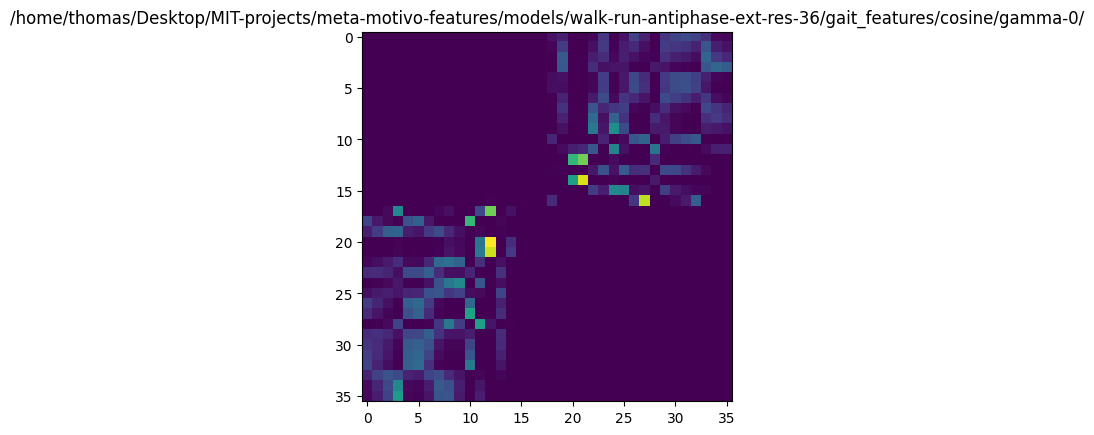

In [4]:
# BT == 0 is original, BT > 1 are permuted p(u|m)
NBTs = 1 #1000

for BT in range(NBTs):

    # # ==> ARGMAX encoders
    # pW_M_en = loadmat(dr + 'pW_M_argmax_MIT.mat') 
    # pW_M_en = pW_M_en['pW_M_argmax'] 
    # np.save('pW_M_en_MIT.npy',pW_M_en)
    # pW_M_en = loadmat(dr + 'pW_M_argmax_english.mat') 
    # pW_M_en = pW_M_en['pW_M_argmax'] 
    # np.save('pW_M_en.npy',pW_M_en)
    # # ==> Spanish
    # pW_M_es = loadmat(dr + 'pW_M_argmax_spanish.mat')
    # pW_M_es = pW_M_es['pW_M_argmax']
    # np.save('pW_M_es.npy',pW_M_es)
    # # ==> Dutch
    # pW_M_du = loadmat(dr + 'pW_M_argmax_dutch.mat')
    # pW_M_du = pW_M_du['pW_M_argmax']
    # np.save('pW_M_du.npy',pW_M_du)
    # # ==> Japanese
    # pW_M_ja = loadmat(dr + 'pW_M_argmax_japanese.mat')
    # pW_M_ja = pW_M_ja['pW_M_argmax']
    # np.save('pW_M_ja.npy',pW_M_ja)
    
    # # ==== raw data from similarity and prior elicitation experiment
    # sm = loadmat(dr + 'sm.mat')
    # sm = sm['sm'] #
    # np.save(dr + 'sm.npy',sm)
    
    # pM_raw_mu = loadmat(dr + 'pM_prolific_mean.mat')
    # pM_raw_mu = pM_raw_mu['pm'] #
    # np.save(dr + 'pM_prolific_mean.npy',pM_raw_mu)
    
    # pM_raw = loadmat(dr + 'pM_prolific.mat')
    # pM_raw = pM_raw['pm_elicit'] #
    # np.save(dr + 'pM_prolific.npy',pM_raw)
    
    # labels = loadmat(dr + 'labels.mat')
    # labels = labels['labels'] 
    # malt_labels = list()
    # for i in range(36):
    #     malt_labels.append(labels[0][i][0])
    # np.save(dr + 'labels.npy',malt_labels)
    
    # # ==========================================================
    
    # # ==> MIT prolific experiments
    # pW_M_en = loadmat(dr + 'english_pW_M_MIT.mat')
    # pW_M_en = pW_M_en['pW_M_pro_mu'] #
    # np.save(dr + 'pW_M_en_MIT.npy',pW_M_en)
    # # ==> Malt naming data (empirical human encoders p(w|m))
    # # ==> English
    # pW_M_en = loadmat(dr + 'english_pW_M.mat')
    # pW_M_en = pW_M_en['pW_M']
    # np.save(dr + 'pW_M_en.npy',pW_M_en)
    # # ==> Spanish
    # pW_M_es = loadmat(dr + 'spanish_pW_M.mat')
    # pW_M_es = pW_M_es['pW_M']
    # np.save(dr + 'pW_M_es.npy',pW_M_es)
    # # ==> Dutch
    # pW_M_du = loadmat(dr + 'dutch_pW_M.mat')
    # pW_M_du = pW_M_du['pW_M']
    # np.save(dr + 'pW_M_du.npy',pW_M_du)
    # # ==> Japanese
    # pW_M_ja = loadmat(dr + 'japanese_pW_M.mat')
    # pW_M_ja = pW_M_ja['pW_M']
    # np.save(dr + 'pW_M_ja.npy',pW_M_ja)
    
    # ==> all pickle file IB_naming_model contents (in precisely the correct format!)
    
    # - pM		    capacity-achieving prior over gestures ------ (36,1) numpy array
    pM = loadmat(dr + 'pM' + str(BT) + '.mat')
    pM = pM['pX'].T
    # save matrix
    np.save(dr + 'pM.npy',pM)
    
    # - pU_M		speaker's mental representations, m(u) ------ (36 x 36), numpy array where np.sum(pU_M,1) == 1
    # load meaning matrix m(u)
    mu = loadmat(dr + 'mu-mat' + str(BT) + '.mat')
    m = mu['mu_m']
    # save matrix
    np.save(dr + 'm.npy',m)
    
    # - betas		the values of beta used for the reverse deterministic annealing schedule  ------ (~2000,) numpy array, in ascending order
    bs = loadmat(dr + 'betas' + str(BT) + '.mat')
    bs = bs['betas']
    betas = list()
    for i in range(bs.shape[0]):
        betas.append(bs[i])
    # ==> must reverse order of encoders (from lease complex, to most complex)
    # save list
    #betas = betas[0][::-1]
    np.save(dr + 'betas.npy',betas)
    
    # - IB_curve	the IB curve defined by (I_beta(M;W), I_beta(W;U)) ------ (2,~2000) numpy array
    IB_curve = loadmat(dr + 'IB_curve' + str(BT) + '.mat')
    IB_curve = IB_curve['IB_curve']
    IB_curve = IB_curve.T
    np.save(dr + 'IB_curve.npy',IB_curve)
    
    # - qW_M		the optimal IB encoders (gesture naming systems) for each value of beta ------ list of (36, T) numpy arrays
    qW_M = loadmat(dr + 'qW_M' + str(BT) + '.mat')
    qW_Ms = qW_M['qW_M']
    # ==> must be a list - so convert matrix tensor to a list
    qW_M = list()
    for i in range(qW_Ms.shape[0]):
        qW_M.append(qW_Ms[i])
    # ==> must reverse order of encoders (from lease complex, to most complex)
    qW_M = qW_M[::-1]
    # save list of encoders
    np.save(dr + 'qW_M.npy',qW_M)
    
    # load meaning matrix
    pU_M = np.load(dr + 'm.npy')
    # load betas
    betas = np.load(dr + 'betas.npy')
    # for IB naming model input pickle file, this needs to be transposed
    # pU_M = pU_M.T
    # check
    # assert(((np.sum(pU_M,1) - 1) < sys.float_info.epsilon * 10).all())
    # ==> load pM
    pM = np.load(dr + 'pM.npy')
    
    # =========== RUN FIXED CATS ALGORITHM TO OUTPUT CORRECT Q(W|M)S =============
    
    # ==> qW_Ms contains all theoretical encoders
    qW_Ms = qW_M.copy() # *****
    
    PRECISION = 1e-16
    eps = .01 #0.01  # .1
    precision =  1e-16
    nM = len(pM)
    nb = len(betas) # *****
    # nb = 1            # *****
    qW_M_fix = [None] * nb
    
    # ==> run fixed_cats
    qW_M = fix_cats(nM,nb,qW_Ms,eps,precision)
    
    # ================== create gestures IB model pickle file ==================
    # ==> do you want to recompute the model lickle file?
    CREATE_PICKLE = True

    # Model
    # =====
    
    # The model .pkl file contains a python dict object with the following fields:
    
    # - pM		    capacity-achieving prior over gestures ------ (36,1) numpy array
    # - pU_M		speaker's mental representations, m(u) ------ (36 x 36), numpy array where np.sum(pU_M,1) == 1
    # - betas		the values of beta used for the reverse deterministic annealing schedule  ------ (~2000,) numpy array, in ascending order
    # - IB_curve	the IB curve defined by (I_beta(M;W), I_beta(W;U)) ------ (2,~2000) numpy array
    # - qW_M		the optimal IB encoders (gesture naming systems) for each value of beta ------ list of (36, T) numpy arrays
    
    if CREATE_PICKLE:
        # Store the arrays in a dictionary
        data = {'pM': pM, 'pU_M': pU_M, 'betas': betas, 'IB_curve': IB_curve, 'qW_M': qW_M}
        
        # Open a file in binary write mode
        with open(dr + 'IB_gestures_model_BT' + str(BT)  + '.pkl', 'wb') as f:
            # Pickle the dictionary and write it to the file
            pickle.dump(data, f)
    
        with open(model_dr + 'model_BT' + str(BT)  + '.pkl', 'wb') as f:
            # Pickle the dictionary and write it to the file
            pickle.dump(data, f)        
    
    print('Done saving model pickle file ' + str(BT) + ' of ' + str(NBTs) + '...')

    #plt.imshow(pM)
    plt.title(model_dr)
    plt.imshow(pU_M)

In [4]:
# # ======================== SANITY CHECK - MY PICKLE SHOULD BE IDENTICAL IN FORMAT TO COLOR EX
# # ==> inspect color example pickle file
# IB_color_naming = '/home/thomas/Downloads/IB_color_naming_model/IB_color_naming.pkl'

# with open(IB_color_naming, 'rb') as f:
#     data = pickle.load(f)

# pM = data['pM']
# print(pM.shape)
# pU_M = data['pU_M']
# print(pU_M.shape)
# betas = data['betas']
# print(betas.shape)
# IB_curve = data['IB_curve']
# print(IB_curve.shape)
# qW_M = data['qW_M']
# print(qW_M[20].shape)